<a href="https://colab.research.google.com/github/xolidausmonovaa-lang/ctf-game-hacking/blob/main/Nafisa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

In [ ]:
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)
df.head()



Saving archive (1).zip to archive (1) (1).zip


,"In general, how worried are you about earthquakes?","How worried are you about the Big One, a massive, catastrophic earthquake?","Do you think the ""Big One"" will occur in your lifetime?",Have you ever experienced an earthquake?,"Have you or anyone in your household taken any precautions for an earthquake (packed an earthquake survival kit, prepared an evacuation plan, etc.)?",How familiar are you with the San Andreas Fault line?,How familiar are you with the Yellowstone Supervolcano?,Age,What is your gender?,How much total combined money did all members of your HOUSEHOLD earn last year?,US Region
0,Not at all worried,Not so worried,No,"Yes, one or more minor ones",No,Somewhat familiar,Not so familiar,18 - 29,Male,Prefer not to answer,New England
1,Somewhat worried,Very worried,No,"Yes, one or more minor ones",No,Not at all familiar,Not at all familiar,18 - 29,Male,"$75,000 to $99,999",East North Central
2,Not so worried,Somewhat worried,No,"Yes, one or more minor ones",No,Very familiar,Somewhat familiar,18 - 29,Male,"$10,000 to $24,999",Pacific
3,Not so worried,Not so worried,No,"Yes, one or more minor ones",No,Very familiar,Not so familiar,18 - 29,Male,"$25,000 to $49,999",West South Central
4,Not so worried,Not so worried,Yes,"Yes, one or more minor ones",No,Somewhat familiar,Extremely familiar,18 - 29,Male,"$200,000 and up",Middle Atlantic


In [ ]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1013 entries, 0 to 1012
Data columns (total 11 columns):
 #   Column                                                                                                                                                Non-Null Count  Dtype 
---  ------                                                                                                                                                --------------  ----- 
 0   In general, how worried are you about earthquakes?                                                                                                    1013 non-null   object
 1   How worried are you about the Big One, a massive, catastrophic earthquake?                                                                            1013 non-null   object
 2   Do you think the "Big One" will occur in your lifetime?                                                                                               1013 non-null   object
 3 

In [ ]:
# bo‘sh qiymatlarni olib tashlash
df = df.dropna()

# faqat sonli ustunlarni olish
df_num = df.select_dtypes(include=['int64', 'float64'])
df_num.head()

""
0
1
2
3
4


Saving archive (1).zip to archive (1) (5).zip


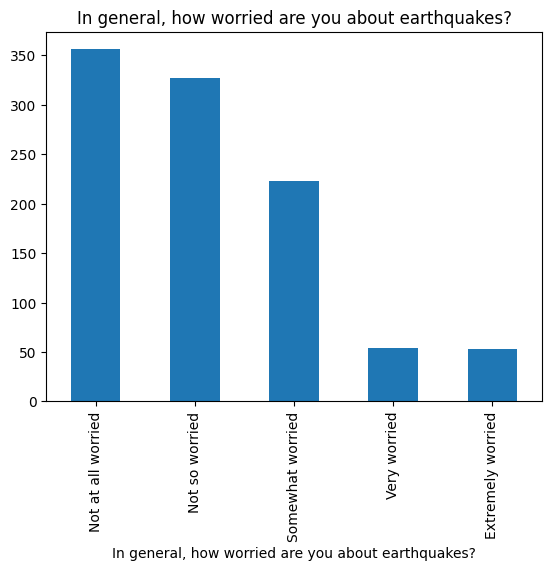

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
import zipfile
import os

# yuklash
uploaded = files.upload()
zip_name = list(uploaded.keys())[0]

# zip ochish
with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall()

# csv topish
csv_file = [f for f in os.listdir() if f.endswith('.csv')][0]

# o‘qish
df = pd.read_csv(csv_file)

# 1 ta ustunni grafik qilish (birinchi ustun)
col = df.columns[0]

df[col].value_counts().head(10).plot(kind='bar')
plt.title(col)
plt.show()



In [ ]:
# oxirgi ustunni target qilamiz
target_col = df.columns[-1]

# kategoriyaga aylantiramiz (ko‘p uchraydigan 2 ta qiymat)
y = df[target_col]

# faqat eng ko‘p uchraydigan 2 ta qiymatni olamiz
top_values = y.value_counts().index[:2]
df_clf = df[df[target_col].isin(top_values)]

In [ ]:
X = df_clf.drop(columns=[target_col])

# hammasini sonlarga o‘tkazamiz
X = X.apply(lambda x: pd.factorize(x)[0])

y = df_clf[target_col]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


In [ ]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7945205479452054


XULOSA:

Ushbu tartibda zilzila ma'lumotlari tahlil bahosi.
Ma'lumotlar vizualizatsiya.
Tasniflash algoritmi (Random Forest) qo'llanildi.
Model ma'lumotlar ma'lumotlariga ajratildi.
shaxsiy modelning aniqligi (accuracy) hisoblandi.